Author: Georgios Katsanevakis, Kyriacos Skoufaris


The following is an example of use for all the functions, starting from the nominal lattice strengths/elements provided in the acc model gitlab:  https://acc-models.web.cern.ch/acc-models/

To run this file requires the acc-model merged dipole lattice for 106.2, the normal and skew response matrices, my function file, a dictionary with the desired misalignment errors (to be generated from a python file that is inlcuded) and a python environment for xsuite.
The procedure to make such an environment is outlined in https://xsuite.readthedocs.io/en/latest/installation.html


In [1]:
import numpy as np
import xtrack as xt
import xobjects as xo
import pickle
import yaml

#file available at https://gitlab.cern.ch/kskoufar/xutil/-/blob/master/xsuite_utilities.py?ref_type=heads
import xsuite_utilities as xutil

#this is the file with my functions
import functions_for_misalignments as fn

#allows plot manipulations
%matplotlib widget

#defining variables to be used later on
acc_model_path = 'acc_models_fcc_ee_LCC_106.2.0'  # https://gitlab.cern.ch/acc-models/fcc/acc-models-fcc-ee/-/tree/LCC_106.2.0?ref_type=tags
particle = 'positron'
operation_mode = 'z'
file_name = 'fccee_z_merged_dipoles'

#dictionary with study parameters
study_param={}
#number of turns for tracking
study_param['number_of_turns'] = 2500
#normalised emittances
study_param['ini_cond_nemittance_x'] = 0.7138e-9
study_param['ini_cond_nemittance_y'] = 0.7138e-12
study_param['ini_cond_type'] = 'grid_MA'
study_param['ini_cond_bunch_length']=0.004860455626868767
study_param['ini_cond_energy_spread']=0.0003736678561994034

/root/miniforge3/envs/xsuite_fcc_com/lib/python3.11/site-packages/htcondor/__init__.py:49: UserWarning: Neither the environment variable CONDOR_CONFIG, /etc/condor/, /usr/local/etc/, nor ~condor/ contain a condor_config source. Therefore, we are using a null condor_config.
  _warnings.warn(message)


In [2]:
#Load environment from acc models
env = xt.Environment.from_json(f'{acc_model_path}/lattices/{operation_mode}/{file_name}.json')

line = env.lines['fccee_p_ring']
line.config.XTRACK_USE_EXACT_DRIFTS = False

# #Set the local context
# context = xo.ContextCpu()         # For CPU
# context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU parallelization

# # Transfer lattice on context and compile tracking code
# line.build_tracker(_context=context)

# Cycle the line now to have the correct initialitation of the beam 
line.cycle(name_first_element='rf400', inplace=True)

Loading line from dict:   0%|          | 0/14697 [00:00<?, ?it/s]

Line(mode=normal, 21288 elements)

In [3]:
# Introduce orbit corrector elements.
fn.add_steering_correctors(line, corrector_names=['Quadrupole'], corrector_prefix=['hcor_', 'vcor_'],corrector_plane='hv')
tt = line.get_table(attr=True)

# Optics correctors introduced to ideal line, needed to compute the response matrix. 
optics_correctors=fn.add_optics_correctors(line, corrector_names = ['Sextupole'], corector_type = [['knl1']])
skew_optics_correctors=fn.add_optics_correctors(line, corrector_names = ['Sextupole'], corector_type = [['ksl1']])

In [4]:
# Remove syncrhotron radiation for optics and orbit correction
line.configure_radiation(model=None, model_beamstrahlung=None)


## Since the sexutpoles will be turned off, computing the chromatic properties might cause problems. Full reference twiss is computed after the sextupole ramping.
tw_ref = line.twiss4d(compute_chromatic_properties=False,coupling_edw_teng=True)

ideal_line=line.copy()

In [ ]:
#Loading the dictionary with the parameters for the errors
with open('misalignment_parameters.yaml', 'r') as f:
    misalignment_errors = yaml.safe_load(f)
seed=misalignment_errors['arc_quads']['error_seed']

#Introducing the misalignments and rotations to the line elements
misalignment_arc_quad=fn.add_misalignment_error(line,misalignment_errors['arc_quads'])

misalignment_dipole=fn.add_misalignment_error(line, misalignment_errors['arc_dipoles'])

misalignment_sextupole=fn.add_misalignment_error(line, misalignment_errors['arc_sextupoles'])

misalignment_girder=fn.add_misalignment_error(line, misalignment_errors['girder'])

misalignment_quad_SS=fn.add_misalignment_error(line, misalignment_errors['SS_quads'])

misalignment_non_arc_dipoles=fn.add_misalignment_error(line, misalignment_errors['non_arc_dipoles'])

misalignment_fd_to_cs=fn.add_misalignment_error(line, misalignment_errors['fd_to_cs'])

misalignment_final_doublet=fn.add_misalignment_error(line, misalignment_errors['final_doublet'])

misalignment_bpm=fn.add_misalignment_error(line, misalignment_errors['bpm'] )


# #Knobs to control what misalignments are applied. By default the variable is 1 (100% of the assigned value)
# line.vars['misalignment_dipoles']= 
# line.vars['misalignment_quads']=
# line.vars['misalignment_sextupoles']= 
# line.vars['misalignment_girder']= 
# line.vars['misalignment_ss_quads']= 
# line.vars['misalignment_non_arc_dipoles']=
# line.vars['misalignment_fd_to_cs']= 
# line.vars['misalignment_final_doublet']= 


tt = line.get_table(attr=True)

In [ ]:
#Turning off the sextupoles
#if custom flag is True, the names of the sextupoles to be modified can be given manually through the "family_name" input. An example input would be family_name='S[FD][12][AB].*' 
#the variable to control the sextupole strengths will be k2n.weight_{family_name} in this case 'k2n.weight_S[FD][12][AB].*'
# fn.sextupoles_strength_edit2 (line, family_name='S[FD][12][AB].*|S[FD][1234][CIJDFM][LR].*', error_strength=0, custom=True)
# fn.sextupoles_strength_edit2 (line, family_name='SCRAB[LR].*|S[FD][MXY][12][LR].*', error_strength=0, custom=True)

fn.sextupoles_strength_edit2(line, family_name='ir', error_strength=0)
fn.sextupoles_strength_edit2(line, family_name='arc', error_strength=0)

In [ ]:
# #add here the function to randomly exclude some orbit correctors or bpms
# element_list=[tt.rows['bpm.*'].name] #/ [tt.rows['hcor.*'].name] / tt.rows['vcor.*'].name
# switch_rate = 0.1 #each element has a 10% chance of being removed
# new_element_list, removed_element_list= fn.off_switch(element_list, switch_rate)



#Assign the BPM's as steering monitors for the line
steering_monitors=tt.rows['bpm.*'].name
line.steering_monitors_x = steering_monitors
line.steering_monitors_y = steering_monitors

#Assign the orbit correctors as steering correctors for the line
line.steering_correctors_x = tt.rows['hcor.*'].name
line.steering_correctors_y = tt.rows['vcor.*'].name

#Initialisation of the orbit correction routine. 'run=False' allows for evaluation of the orbit response matrix without applying the correction, 
#providing the singular values used to find the cutoff BPM misalignments are introduced through the 'monitor_alignment' parameter
orbit_correction = line.correct_trajectory(twiss_table=tw_ref,monitor_alignment=misalignment_bpm, run=False)

#Singular values of the orbit correction, used to determine the cutoff 
x_sv = orbit_correction.x_correction.singular_values
y_sv = orbit_correction.y_correction.singular_values

#Amount of singular values used in orbit correction. This value has been determined for LCC v106.2.
# It is possible to introduce the misalignments adiabatically (with the aforementioned knobs) and avoid the SVD orbit cutoff.
cutoff=1300

#Sometimes threading is neccessary. 'delta0=0' ensures no radiation efffects are considered. Performing 2 SVD's seemed to provide an improved solution without significant computational
#time increase. 

#To be checked: PySC functionality for orbit correction https://indico.cern.ch/event/1663665/contributions/6994658/attachments/3242228/5783534/20260320_pySC_and_commissioning_simulations_petra4.pdf

#The orbit correction can also be performed with MICADO. n_micado controls the amount of correctors in each plane that will be used, and 
#n_iter the amount of iterations performed. n_micado and n_iter need to be optimised, random values are provided below.
# orbit_correction = line.correct_trajectory(twiss_table=tw_ref, n_micado=12,n_iter=4)



try:
    orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
    orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
except Exception as e:
    print(f"Threading Neccessary: {e}")
    threader = orbit_correction.thread(ds_thread=4000, rcond_long=1e-5)
    orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
    orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)


#Ramp up the sextupoles (arc and ir can be ramped separately or together)
for i in [0.25, 0.5, 0.75,1]:
    line.vars['k2n.weight_arc']=i
    # line.vars['k2n.weight_ir']=i

    orbit_correction = line.correct_trajectory(twiss_table=tw_ref,monitor_alignment=misalignment_bpm, run=False)

    x_sv = orbit_correction.x_correction.singular_values
    y_sv = orbit_correction.y_correction.singular_values
    try:
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
    except Exception as e:
        print(f"Threading Neccessary: {e}")
        threader = orbit_correction.thread(ds_thread=4000, rcond_long=1e-5) 
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)

for i in [0.25, 0.5, 0.75,1]:
    line.vars['k2n.weight_ir']=i
    orbit_correction = line.correct_trajectory(twiss_table=tw_ref,monitor_alignment=misalignment_bpm, run=False)
    x_sv = orbit_correction.x_correction.singular_values
    y_sv = orbit_correction.y_correction.singular_values
    try:
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
    except Exception as e:
        print(f"Threading Neccessary: {e}")
        threader = orbit_correction.thread(ds_thread=4000, rcond_long=1e-5) #1e-7
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)
        orbit_correction.correct(n_singular_values=(cutoff,cutoff),delta0=0)

    try:
        fn.match_tune_chroma(line, tw_ref, match_quantities='tune')
    except Exception as e:
        print(f"Tune matching failed: {e}")



Warning! Need second attempt on closed orbit search


Threading Neccessary: 
Stop at s=4000, global rms = [x: 2.32e-04 -> 4.64e-06, y: 2.72e-04 -> 1.12e-05]
Stop at s=8000, global rms = [x: 3.83e-04 -> 3.59e-06, y: 8.46e-04 -> 7.62e-06]
Stop at s=12000, global rms = [x: 4.18e-03 -> 3.97e-06, y: 3.32e-03 -> 9.80e-06]
Stop at s=16000, global rms = [x: 6.04e-03 -> 4.85e-05, y: 1.61e-02 -> 1.06e-04]
Stop at s=20000, global rms = [x: 1.42e-04 -> 2.32e-06, y: 4.70e-04 -> 5.22e-06]
Stop at s=24000, global rms = [x: 7.86e-05 -> 2.38e-06, y: 4.04e-04 -> 4.82e-06]
Stop at s=28000, global rms = [x: 4.71e-05 -> 1.61e-06, y: 5.60e-05 -> 4.43e-06]
Stop at s=32000, global rms = [x: 1.98e-04 -> 2.04e-06, y: 2.08e-04 -> 4.38e-06]
Stop at s=36000, global rms = [x: 3.56e-03 -> 7.23e-06, y: 5.21e-04 -> 6.95e-06]
Stop at s=40000, global rms = [x: 4.04e-05 -> 6.81e-06, y: 1.42e-04 -> 4.81e-06]
Stop at s=44000, global rms = [x: 4.23e-05 -> 6.45e-06, y: 8.97e-05 -> 4.57e-06]
Stop at s=48000, global rms = [x

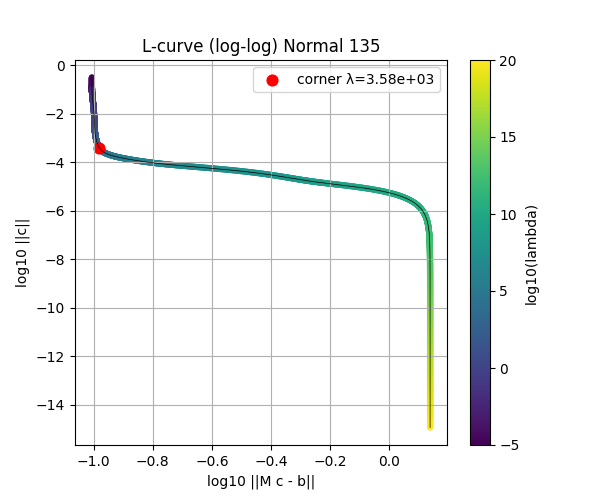

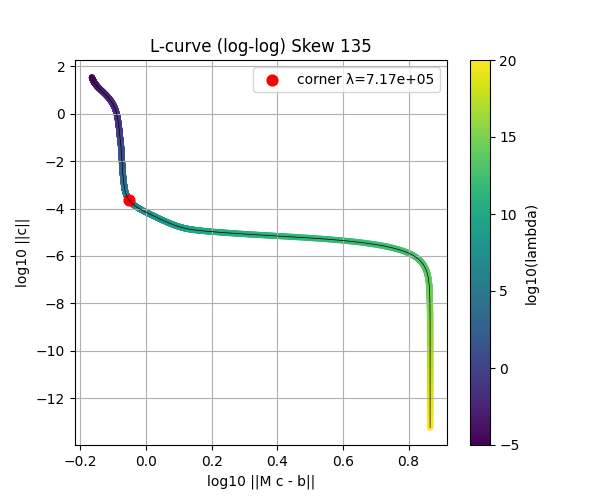

In [ ]:
#Re-evaluate the reference twiss with chromatic functions and the coupling RDT's (mask 'coupling_edw_teng')
tw_ref = ideal_line.twiss4d(coupling_edw_teng=True)


#The response matrices are provided. To compute them (from the ideal line) the "response_matrix" function is to be used. 
# response_matrix=fn.response_matrix(ideal_line,observables=['mux', 'muy', 'dx'], obs_points=tt.rows['bpm.*'].name.tolist(), 
#                  corr_elements=[f"knl1{elem}" for elem in optics_correctors[1]], dk=1e-5, bipolar=True)

# skew_response_matrix=fn.response_matrix(ideal_line,observables=['f1001_real', 'f1001_imag','f1010_real', 'f1010_imag', 'dy'], obs_points=tt.rows['bpm.*'].name.tolist(), 
#                  corr_elements=[f"knl1{elem}" for elem in skew_optics_correctors[0]], dk=1e-5,rdt=None bipolar=True)


#Loading pre-computed responce matrix for normal quadrupole correctors
#'data' is a dictionary that contains the response matrix, the observables used, the observation points considered
#and the correctors used
with open("response_matrix(1e-5)_2.pkl", "rb") as f:
    data = pickle.load(f)
response = data["response"]
observables=data['observables']
obs_points=data["obs_points"]
corr_elements=data["corr_elements"]
corr_elements_func = [s[len("knl1"):] for s in corr_elements]

#Tikhonov regularisation. 'b' is the difference vector between the observables at the BPM's in the ideal and current line
#The tikhonov function returns a plot to verify the correct lambda was chosen, as well as its value, used in the computation
#of the pseudoinverse
b=fn.get_delta_vec(twiss=line.twiss4d(), reference_twiss=tw_ref,observables= observables)
lambda_opt, c_opt=fn.tikhonov_lcurve(response, b, lambdas=np.logspace(-5,20, 2000), plot=True, title=f"Normal {seed}")
pseudo_inverse=fn.pseudo_inverse(responce_matrix=response, Tikhonov_lambda=lambda_opt)

#Loading pre-computed responce matrix for skew quadrupole correctors
#'data' is a dictionary that contains the response matrix, the observables used, the observation points considered
#and the correctors used
with open("responce_matrix_rdt_1e-5_not_tog_moreBPM_2.pkl", "rb") as f:
    data_skew = pickle.load(f)
response_skew = data_skew["response"]
observables_skew=data_skew['observables']
obs_points_skew=data_skew["obs_points"]
corr_elements_skew=data_skew["corr_elements"]
corr_elements_func_skew = [s[len("ksl1"):] for s in corr_elements_skew]

#Regularisation for response matrix for skew correctors
b_skew=fn.get_delta_vec(twiss=line.twiss4d(coupling_edw_teng=True), reference_twiss=tw_ref,observables= observables_skew, rdt=True)
lambda_opt_skew, c_opt_skew=fn.tikhonov_lcurve(response_skew, b_skew, lambdas=np.logspace(-5,20, 2000), plot=True, title=f"Skew {seed}")
pseudo_inverse_skew=fn.pseudo_inverse(responce_matrix=response_skew, Tikhonov_lambda=lambda_opt_skew)


In [ ]:
#5 iterations of optics correction. Chromaticity correction at the end. Further optics corrections
#can be performed after chromaticity, here was not found to affect results
for i in range(5):
    #Normal correctors are changed
    tw_optics=fn.optics_corrections(line,observables=observables,
                            observation_points=obs_points, reference_twiss=tw_ref, 
                            correctors=corr_elements, p_inverse=pseudo_inverse, weight=1)
    #Skew correctors are changed, flag "rdt=True" for coupling Resonance Driving Terms  as observables                    
    tw_optics_skew=fn.optics_corrections(line,observables=observables_skew,
                            observation_points=obs_points_skew, reference_twiss=tw_ref, 
                            correctors=corr_elements_skew, p_inverse=pseudo_inverse_skew, rdt=True, weight=1)

#Chromaticity correction
fn.match_tune_chroma(line, tw_ref, match_quantities='chroma')

tw_optics_skew=line.twiss4d(coupling_edw_teng=True)

                                             
Optimize - start penalty: 0.3473                            
Matching: model call n. 8 penalty = 3.6031e-07              
Optimize - end penalty:  3.60311e-07                            
Target status:               alty = 3.6031e-07              
id state tag   tol_met       residue   current_val    target_val description                           
0  ON    chrom    True   3.91913e-08       12.1114       12.1114 'dqx', val=12.1114, tol=0.01, weight=1
1  ON    chrom    True   3.58173e-07       5.24097       5.24097 'dqy', val=5.24097, tol=0.01, weight=1
Vary status:                 
id state tag  met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON    sext OK  ksd2 None            -0.176481 None            -0.176755         0.001             1
1  ON    sext OK  ksf2 None             0.230749 None             0.230903         0.001             1
2  ON    sext OK  ksf1 None             0.319749 None  

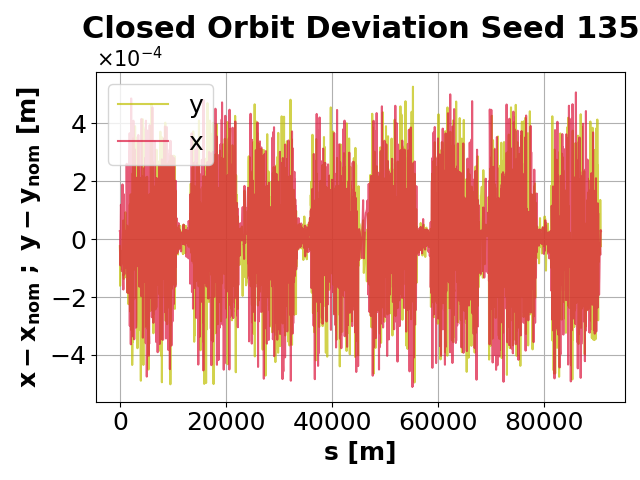

DeltaQx : 9.44e-05,  DeltaQy : -5.29e-06


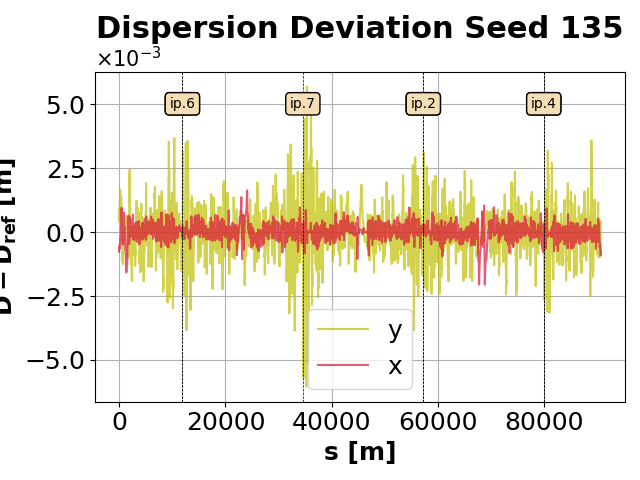

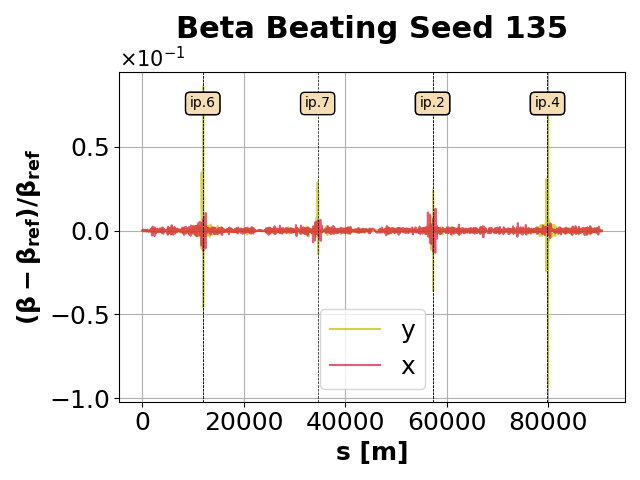

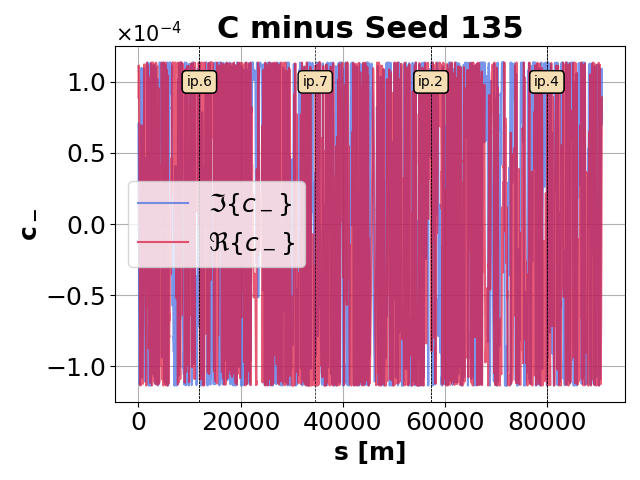

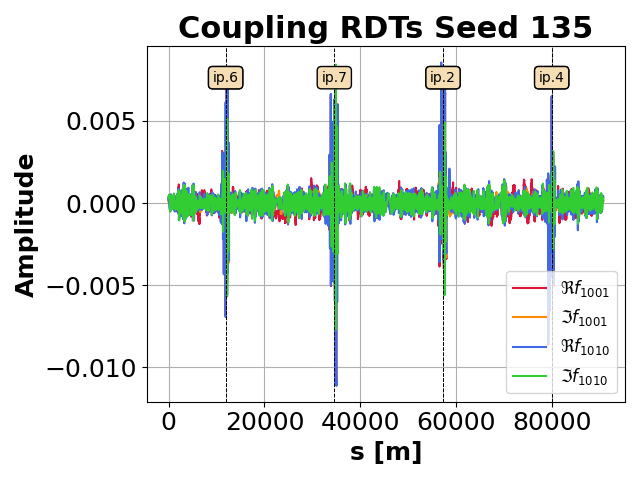

Chroma Diff x : 0.000419,  Chroma Diff y : 0.00977


In [ ]:
#Plotting function to examine the results
x,y=fn.closed_orbit_vs_s(tw_ref,  tw_optics_skew,  outline=None)
print(f'DeltaQx : {(tw_ref.qx-tw_optics_skew.qx):.3g},  DeltaQy : {(tw_ref.qy-tw_optics_skew.qy):.3g}')
dx_rms,dy_rms=fn.dispersion_deviation_vs_s(tw_ref, tw_optics_skew)
betx_rms,bety_rms=fn.beta_beating_vs_s(tw_ref, tw_optics_skew, zoom=None)
coupling_rms_re,coupling_rms_im=fn.coupling_vs_s(tw_optics_skew)
rdt_rms = fn.coupling_rdt_single(tw_optics_skew)
print(f'Chroma Diff x : {(tw_ref.dqx-tw_optics_skew.dqx):.3g},  Chroma Diff y : {(tw_ref.dqy-tw_optics_skew.dqy):.3g}')

In [ ]:
#Introduce Synchrotron Radiation and compensate its effects with magnetic tapering for both the line with errors and the ideal one
line.configure_radiation(model='mean')
line.compensate_radiation_energy_loss()

ideal_line.configure_radiation(model='mean')
ideal_line.compensate_radiation_energy_loss()

#One iteration of optics correction to correct the phase advances 
tw_optics=fn.optics_corrections(line,observables=observables,
                        observation_points=obs_points, reference_twiss=tw_ref, 
                        correctors=corr_elements, p_inverse=pseudo_inverse, Delta_mu=False,radiation=True, weight=1)
tw_optics_skew=fn.optics_corrections(line,observables=observables_skew,
                        observation_points=obs_points_skew, reference_twiss=tw_ref, 
                        correctors=corr_elements_skew, p_inverse=pseudo_inverse_skew, rdt=True, radiation=True, weight=1)

#Match the chromaticity after enabling radiation
fn.match_tune_chroma(line, tw_ref, match_quantities='chroma')

#Compute twiss with "eneloss_and_damping=True" flag to consider synchrotron radiation
tw_optics_skew=line.twiss(coupling_edw_teng=True, eneloss_and_damping=True)
tw_ref = ideal_line.twiss(coupling_edw_teng=True, eneloss_and_damping=True)

                                             
Optimize - start penalty: 0.03268                           
Matching: model call n. 8 penalty = 2.5496e-06              
Optimize - end penalty:  2.54956e-06                            
Target status:               alty = 2.5496e-06              
id state tag   tol_met       residue   current_val    target_val description                           
0  ON    chrom    True  -2.54386e-06       12.1114       12.1114 'dqx', val=12.1114, tol=0.01, weight=1
1  ON    chrom    True  -1.70421e-07       5.24097       5.24097 'dqy', val=5.24097, tol=0.01, weight=1
Vary status:                 
id state tag  met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON    sext OK  ksd2 None            -0.176473 None            -0.176481         0.001             1
1  ON    sext OK  ksf2 None             0.230717 None             0.230749         0.001             1
2  ON    sext OK  ksf1 None             0.319718 None  

In [ ]:
#Set the context for particle tracking to "auto" to reduce computational time
context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU parallelization


## Transfer lattice on context and compile tracking code
line.build_tracker(_context=context)

#Generate particle grid for Momentum Aceptance
if study_param['ini_cond_type'] == 'grid_MA':
    delta_initial_values = np.linspace(-0.015, 0.015, 100)
    particles_MA, grid_details_MA = xutil.generate_particle_grid (line, study_param, delta_initial_values=delta_initial_values, max_r_y=25) #, max_r_y=20

#Generate particle grid for Dynamic Apperture
study_param['ini_cond_type'] = 'grid_DA'
if study_param['ini_cond_type'] == 'grid_DA':
    particles_DA, grid_details_DA = xutil.generate_particle_grid (line, study_param, cartesian_polar='cartesian') # , max_r_y=30, 

#Enable quantum fluctuations
line.configure_radiation(model='quantum')
line.discard_tracker()
line.build_tracker(_context=context_tracking)

#Particle tracking for DA
line.track(particles_DA, num_turns=study_param['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) 
particles_DA.sort(interleave_lost_particles=True)

#Plot of DA
if study_param['ini_cond_type'] == 'grid_DA':
    x_DA, y_DA, where_min_DA=fn.DA_vs_turns(particles_DA, grid_details_DA['num_r_y_points'], grid_details_DA['num_theta_x_points'], grid_details_DA['x_normalized'], grid_details_DA['y_normalized'], grid_details_DA['delta_init'])

#Particle tracking for MA
line.track(particles_MA, num_turns=study_param['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) 
particles_MA.sort(interleave_lost_particles=True)
study_param['ini_cond_type'] = 'grid_MA'

#Plot of MA
if study_param['ini_cond_type'] == 'grid_MA':
    x_MA, delta_MA, where_min_MA=fn.MA_vs_turns(particles_MA, grid_details_MA['num_r_y_points'], grid_details_MA['num_delta'], grid_details_MA['x_normalized'], grid_details_MA['y_normalized'], grid_details_MA['delta_init'])

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 